In [34]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split

In [2]:
#Dataloading
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

c:\Users\xx\Desktop\CIFAR10\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=101)

In [10]:
X_train.shape, y_train.shape

((45000, 32, 32, 3), (45000, 1))

In [11]:
X_valid.shape, y_valid.shape

((5000, 32, 32, 3), (5000, 1))

In [12]:
X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [4]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

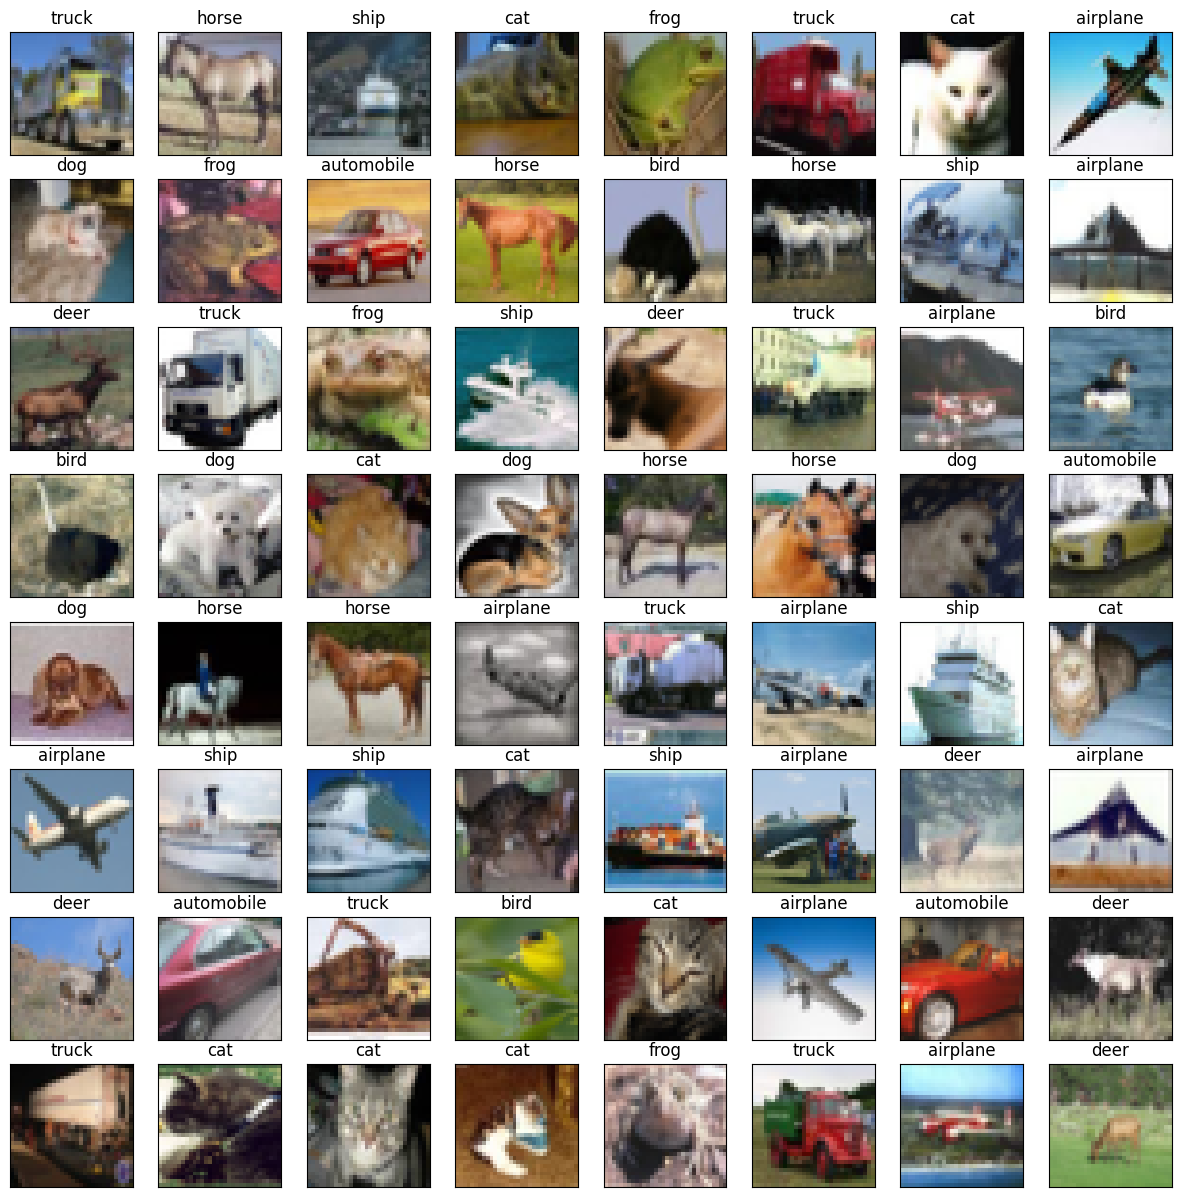

In [19]:
plt.figure(figsize=(15,15))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
plt.show()

#Normalization

In [6]:
#Converting images to float 32

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_valid = X_valid.astype('float32')

#Calc mean and std
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean)/(std + 0.0000001)
X_test = (X_test - mean)/(std + 0.0000001)
X_valid = (X_valid - mean)/(std + 0.0000001)

One hot encoding of labels

In [7]:
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)
y_test = to_categorical(y_test, 10)

Data augmentation

In [24]:
data_generator = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = .12,
    height_shift_range = .12,
    horizontal_flip = True,
    zoom_range = .1,
    brightness_range = [0.9, 1.1],
    shear_range = 10,
    channel_shift_range = .1,
)

Model

In [26]:
model = Sequential()

weight_decay = 0.0001

model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay), input_shape = X_train.shape[1:]))
model.add(BatchNormalization())

model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

#Add max pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))
#Add dropout layer
model.add(Dropout(rate=0.2))

#Add 3rd n 4th layers
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

#Add max pooling layer 2nd
model.add(MaxPooling2D(pool_size=(2, 2)))
#Add dropout layer
model.add(Dropout(rate=0.3))

#Add 5th n 6th layers
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

#Add max pooling layer 3rd
model.add(MaxPooling2D(pool_size=(2, 2)))
#Add dropout layer
model.add(Dropout(rate=0.4))

#Add 5th n 6th layers
model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation = 'relu', kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

#Add max pooling layer 4th
model.add(MaxPooling2D(pool_size=(2, 2)))
#Add dropout layer
model.add(Dropout(rate=0.5))

#Flatten tensor output
model.add(Flatten())

#Add a fully connected layer with softmax act func
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,186,346 (4.53 MB)

 Trainable params: 1,184,426 (4.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
batch_size = 64

epochs = 150

optimizer = Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer, loss = 'categorical_crossentropy', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

ealry_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

model.fit(data_generator.flow(X_train, y_train, batch_size=batch_size), epochs=epochs, validation_data=(X_valid, y_valid), callbacks = [reduce_lr, ealry_stopping], verbose=2)

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(model.history.history['loss'], label = "Train loss", color = 'blue')
plt.plot(model.history.history['val_loss'], label = "Validation loss", color = 'red')
plt.legend()
plt.title("Loss evolution")

plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'], label = "Train accuracy", color = 'blue')
plt.plot(model.history.history['val_accuracy'], label = "Validation accuracy", color = 'red')
plt.legend()
plt.title("Accuracy evolution")

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose = 1)

print(f'Test accuracy: {test_acc}\nTestloss: {test_loss}')

performance test

In [36]:
url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRtMu7ZbLiSEbu3n6Ilx96aRcyyIH2ccw06rQ&s'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()), dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


<function matplotlib.pyplot.show(close=None, block=None)>

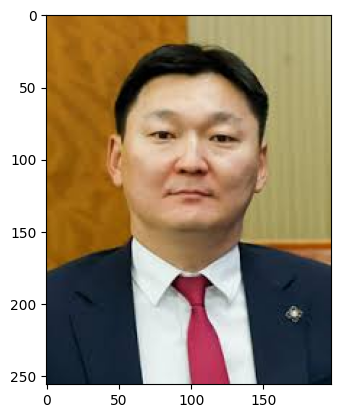

In [37]:
plt.imshow(image)
plt.show

In [38]:
image.shape

(256, 197, 3)

In [39]:
image = cv2.resize(image, (32, 32))
#normalize the image
image = (image-mean)/(std + 0.0000001)
#add an extra dimension because the model expects batch of image
image = image.reshape((1,32,32,3))

In [40]:
predict = model.predict(image)
class_names[predict.argmax()]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


'horse'

c:\Users\xx\Desktop\CIFAR10\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


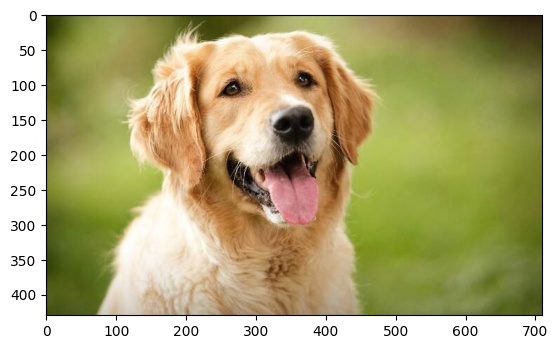

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class: dog


'dog'

In [10]:
from keras.models import load_model
from keras.datasets import cifar10

# Load the saved model
model = load_model('cifar10_trained_model.keras')

# Recalculate mean and std from training data
(X_train_temp, _), (_, _) = cifar10.load_data()
X_train_temp = X_train_temp.astype('float32')
mean = np.mean(X_train_temp)
std = np.std(X_train_temp)

# Function to predict from URL
def predict_from_url(url):
    """
    Download image from URL, display it, resize to 32x32, normalize, and make prediction.
    """
    # Download and load image from URL
    reps = urllib.request.urlopen(url)
    image = np.asarray(bytearray(reps.read()), dtype='uint8')
    image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Display original image
    plt.imshow(image)
    plt.show()
    
    # Resize to 32x32
    image = cv2.resize(image, (32, 32))
    
    # Normalize the image using mean and std from training data
    image = (image - mean) / (std + 0.0000001)
    
    # Add batch dimension because the model expects batch of images
    image = image.reshape((1, 32, 32, 3))
    
    # Make prediction
    predict = model.predict(image)
    predicted_class = class_names[predict.argmax()]
    
    print(f"Predicted class: {predicted_class}")
    return predicted_class

# Example usage with a sample image URL
url = 'https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7'
predict_from_url(url)